In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:
# basic line plot
# Data source: Chesapeake Bay Program Datahub, Water Quality:
# https://datahub.chesapeakebay.net/api/WaterQuality/09-29-2021/09-29-2026/0,1/6/7/Station/1160/16,17,21,30,31,34,35,36,55,60,63,65,67,71,73,74,76,77,78,80,81,82,83,85,87,88,94,104,105,107,108,109,110,111,114,116,121,123
# I downloaded Oct 2021- Sep 2026 data from Station CB4.1C

# import data
infile = '/Users/jsturner/Documents/Teaching_Advising/TEACHING_ODU/2026_Env_Data_Science/data/CBP_TWQM_MAIN_WQ_2021_2026.csv'
data = pd.read_csv(infile, sep=',')

data.columns


Index(['Station', 'FieldActivityId', 'Cruise', 'Program', 'Project',
       'DataCollector', 'DataProvider', 'Latitude', 'Longitude', 'SampleDate',
       'SampleTime', 'TotalDepthM', 'UpperPycnoclineDepthM',
       'LowerPycnoclineDepthM', 'SampleDepthM', 'Layer', 'SampleType',
       'SampleReplicate', 'Parameter', 'Qualifier', 'MeasureValue',
       'MeasureUnit', 'Method', 'Lab', 'Problem', 'PrecisionPC', 'BiasPC',
       'Details', 'TierLevel'],
      dtype='str')

In [5]:
# Look at unique variables, called "Parameter" here
variables = data['Parameter'].unique()
print(variables)

<ArrowStringArray>
[    'CHLA',      'DIN',       'DO',      'DON',      'DOP',       'KD',
     'NH4F',    'NO23F',     'NO2F',     'NO3F',       'PC',       'PH',
     'PHEO',       'PN',     'PO4F',       'PP', 'SALINITY',   'SECCHI',
  'SIGMA_T',   'SPCOND',      'TDN',      'TDP',       'TN',      'TON',
       'TP',      'TSS',    'WTEMP']
Length: 27, dtype: str


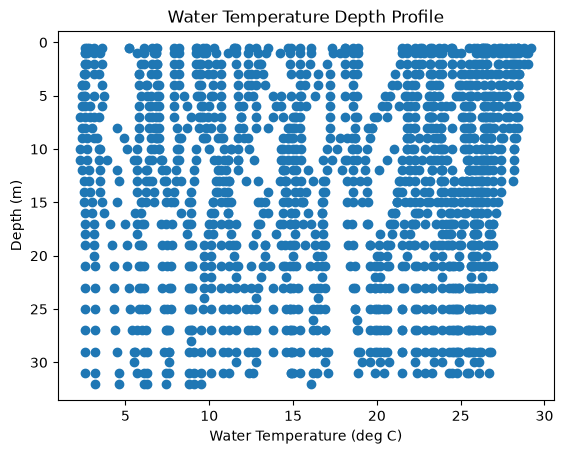

In [6]:
# Filter for WTEMP data
wtemp = data[data['Parameter'] == 'WTEMP']

# Plot WTEMP vs Depth
plt.scatter(wtemp['MeasureValue'], wtemp['SampleDepthM'])
plt.gca().invert_yaxis()  # Inverts y-axis so depth 0 is at the surface
plt.xlabel('Water Temperature (deg C)')
plt.ylabel('Depth (m)')
plt.title('Water Temperature Depth Profiles from CB4.1C')
plt.show()




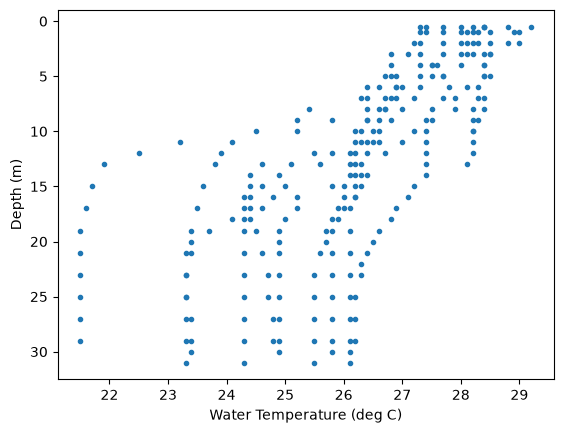

In [26]:
# Subset for only depth profiles with warm temperatures at the surface
# Sort by depth so the surface measurement comes first for each profile
wtemp_sorted = wtemp.sort_values(by=['SampleDate', 'SampleDepthM'])

# Get the shallowest (surface) row for every profile
surface_temps = wtemp_sorted.groupby('SampleDate').first()

# Get list of ProfileIDs where surface MeasureValue > 27
valid_profiles = surface_temps[surface_temps['MeasureValue'] > 27].index

# Filter the original dataset for only those profiles
subset = wtemp[wtemp['SampleDate'].isin(valid_profiles)]

plt.plot(subset['MeasureValue'], subset['SampleDepthM'],'.') # without the '.' this is a crazy squiggle line mess
plt.gca().invert_yaxis()  # Inverts y-axis so depth 0 is at the surface
plt.xlabel('Water Temperature (deg C)')
plt.ylabel('Depth (m)')
plt.show()

In [28]:
# Are there different depth profiles?
print(subset.SampleDate)


12719    2025-07-21
12720    2025-07-21
12721    2025-07-21
12722    2025-07-21
12723    2025-07-21
            ...    
13836    2022-07-26
13837    2022-07-26
13838    2022-07-26
13839    2022-07-26
13840    2022-07-26
Name: SampleDate, Length: 252, dtype: str


In [29]:
profile_id = subset['SampleDate'].unique()
print(profile_id)

<ArrowStringArray>
['2025-07-21', '2025-07-09', '2024-08-13', '2024-07-31', '2024-07-16',
 '2023-09-12', '2023-07-27', '2022-08-23', '2022-08-09', '2022-07-26']
Length: 10, dtype: str


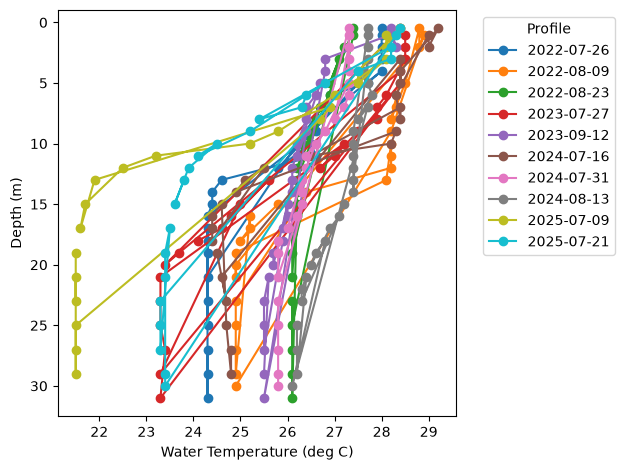

In [31]:
# How to plot these better than we did above???????????

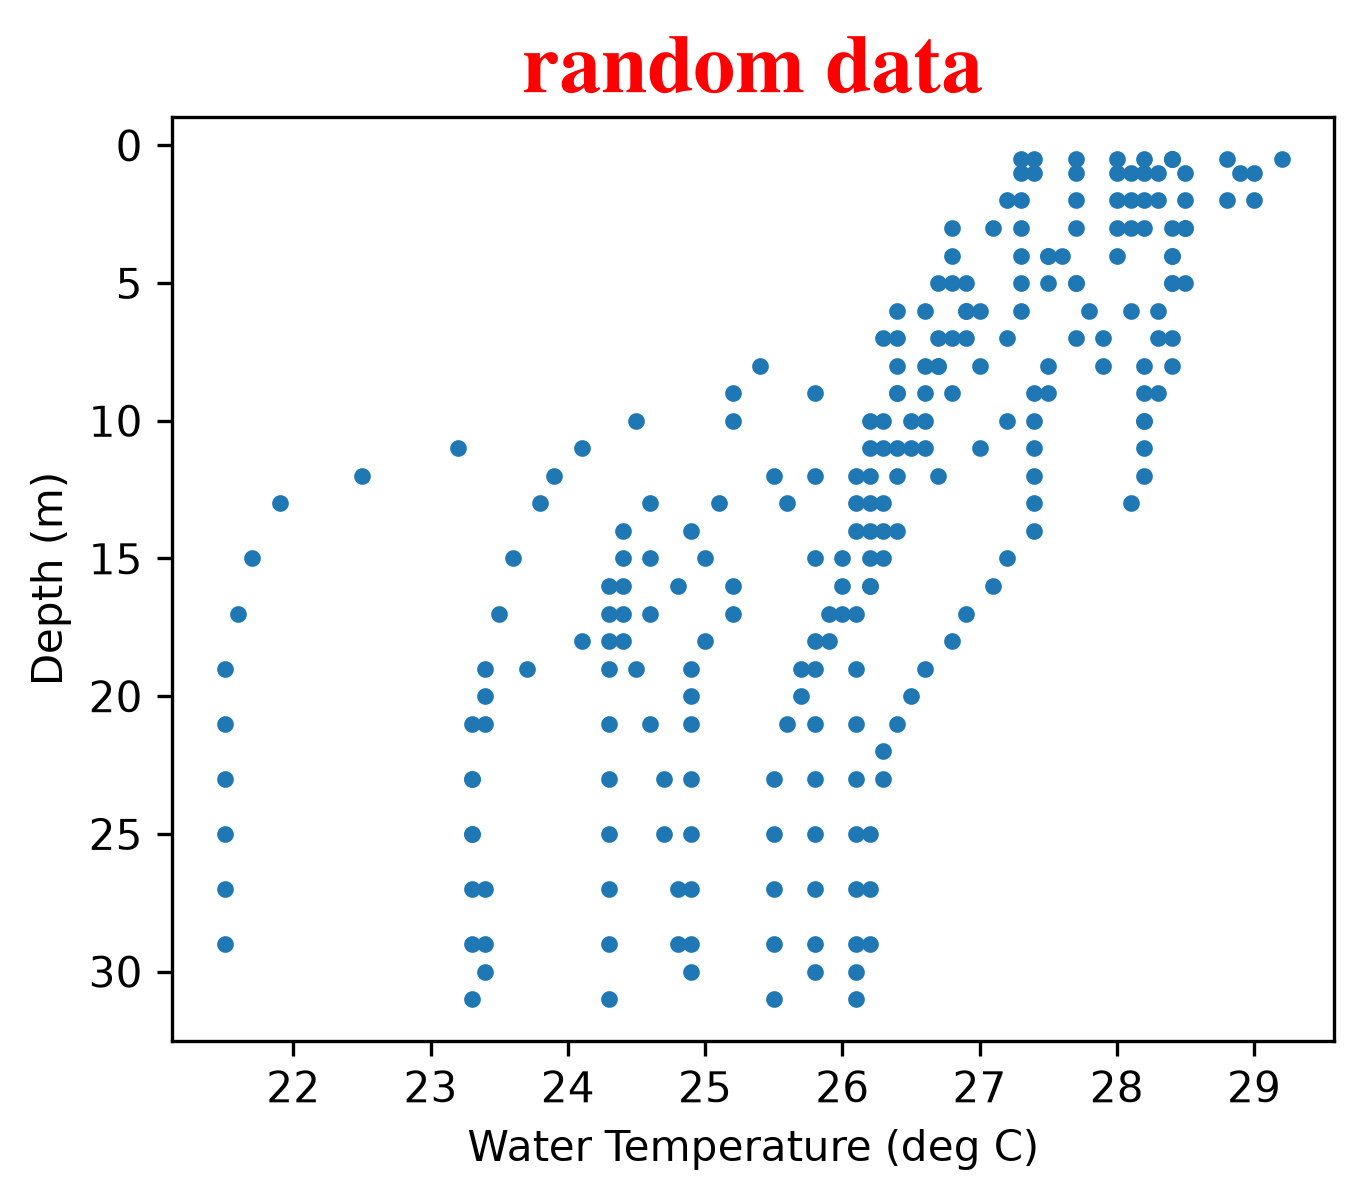

In [41]:
# Example options to change the appearance of your figures:

fig = plt.figure(figsize=(5, 4), dpi = 300)

# Examples: https://matplotlib.org/stable/gallery/text_labels_and_annotations/fonts_demo.html

# font = {'family': 'sansserif', # default is sansserif
#        'color':  'purple',
#        'weight': 'normal',
#        'size': 16,plt.plot(subset['MeasureValue'], subset['SampleDepthM'],'.') # without the '.' this is a crazy squiggle line mess

plt.plot(subset['MeasureValue'], subset['SampleDepthM'],'.') # without the '.' this is a crazy squiggle line mess
plt.gca().invert_yaxis()  # Inverts y-axis so depth 0 is at the surface
plt.xlabel('Water Temperature (deg C)')
plt.ylabel('Depth (m)')

# Uncomment the line below and re-run to try more font options:
#plt.title('Big Title', fontsize = 20, color = 'red', fontname = 'Times', weight = 'bold')

plt.show()

fig.savefig('example.png', dpi = 300)